In [ ]:
## Standard libraries
import os
import json
import math
import time
import numpy as np
import scipy.linalg

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgb
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns
sns.set()

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms
# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "../saved_models/tutorial10"

# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0") # Use GPU if available
print("Using device", device)

/tmp/ipython-input-1624657571.py:13: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export
INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device cuda:0


In [ ]:
import urllib.request
from urllib.error import HTTPError
import zipfile
# Github URL where the dataset is stored for this tutorial
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial10/"
# Files to download
pretrained_files = [(DATASET_PATH, "TinyImageNet.zip"), (CHECKPOINT_PATH, "patches.zip")]
# Create checkpoint path if it doesn't exist yet
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# For each file, check whether it already exists. If not, try downloading it.
for dir_name, file_name in pretrained_files:
    file_path = os.path.join(dir_name, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file from the GDrive folder, or contact the author with the full output including the following error:\n", e)
        if file_name.endswith(".zip"):
            print("Unzipping file...")
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(file_path.rsplit("/",1)[0])

Unzipping file...
Unzipping file...


In [ ]:
# Load CNN architecture pretrained on ImageNet
os.environ["TORCH_HOME"] = CHECKPOINT_PATH
pretrained_model = torchvision.models.resnet34(weights='IMAGENET1K_V1')
pretrained_model = pretrained_model.to(device) # Move model to device

# No gradients needed for the network
pretrained_model.eval()
for p in pretrained_model.parameters():
    p.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to ../saved_models/tutorial10/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 217MB/s]


Dataset

In [ ]:
# Mean and Std from ImageNet
NORM_MEAN = np.array([0.485, 0.456, 0.406])
NORM_STD = np.array([0.229, 0.224, 0.225])

# No resizing and center crop necessary as images are already preprocessed.
plain_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN,
                         std=NORM_STD)
])

# Load dataset and create data loader
imagenet_path = os.path.join(DATASET_PATH, "TinyImageNet/")
assert os.path.isdir(imagenet_path), f"Could not find the ImageNet dataset at expected path \"{imagenet_path}\". " + \
                                     f"Please make sure to have downloaded the ImageNet dataset here, or change the {DATASET_PATH=} variable."
dataset = torchvision.datasets.ImageFolder(root=imagenet_path, transform=plain_transforms)
data_loader = data.DataLoader(dataset, batch_size=32, shuffle=False, drop_last=False, num_workers=8)

# Load label names to interpret the label numbers 0 to 999
with open(os.path.join(imagenet_path, "label_list.json"), "r") as f:
    label_names = json.load(f)

def get_label_index(lab_str):
    assert lab_str in label_names, f"Label \"{lab_str}\" not found. Check the spelling of the class."
    return label_names.index(lab_str)

In [ ]:
def eval_model(dataset_loader, img_func=None):
    tp, tp_5, counter = 0., 0., 0.
    # Use CPU for evaluation
    eval_device = torch.device("cpu")
    pretrained_model.to(eval_device)

    for imgs, labels in tqdm(dataset_loader, desc="Validating..."):
        imgs = imgs.to(eval_device) # Move images to eval_device
        labels = labels.to(eval_device) # Move labels to eval_device
        if img_func is not None:
            imgs = img_func(imgs, labels)
        with torch.no_grad():
            preds = pretrained_model(imgs)
        tp += (preds.argmax(dim=-1) == labels).sum()
        tp_5 += (preds.topk(5, dim=-1)[1] == labels[...,None]).any(dim=-1).sum()
        counter += preds.shape[0]
    acc = tp.float().item()/counter
    top5 = tp_5.float().item()/counter

    # Move model back to original device after evaluation
    pretrained_model.to(device)

    print(f"Top-1 error: {(100.0 * (1 - acc)):4.2f}%")
    print(f"Top-5 error: {(100.0 * (1 - top5)):4.2f}%")
    return acc, top5

In [ ]:
def show_prediction(img, label, pred, K=5, adv_img=None, noise=None):

    # Ensure tensors are on CPU for visualization
    img = img.cpu()
    label = label.cpu()
    pred = pred.cpu()
    if adv_img is not None:
        adv_img = adv_img.cpu()
    if noise is not None:
        noise = noise.cpu()


    if isinstance(img, torch.Tensor):
        # Tensor image to numpy
        img = img.permute(1, 2, 0).numpy()
        img = (img * NORM_STD[None,None]) + NORM_MEAN[None,None]
        img = np.clip(img, a_min=0.0, a_max=1.0)
        label = label.item()

    # Plot on the left the image with the true label as title.
    # On the right, have a horizontal bar plot with the top k predictions including probabilities
    if noise is None or adv_img is None:
        fig, ax = plt.subplots(1, 2, figsize=(10,2), gridspec_kw={'width_ratios': [1, 1]})
    else:
        fig, ax = plt.subplots(1, 5, figsize=(12,2), gridspec_kw={'width_ratios': [1, 1, 1, 1, 2]})

    ax[0].imshow(img)
    ax[0].set_title(label_names[label])
    ax[0].axis('off')

    if adv_img is not None and noise is not None:
        # Visualize adversarial images
        adv_img = adv_img.permute(1, 2, 0).numpy()
        adv_img = (adv_img * NORM_STD[None,None]) + NORM_MEAN[None,None]
        adv_img = np.clip(adv_img, a_min=0.0, a_max=1.0)
        ax[1].imshow(adv_img)
        ax[1].set_title('Adversarial')
        ax[1].axis('off')
        # Visualize noise
        noise = noise.permute(1, 2, 0).numpy()
        noise = noise * 0.5 + 0.5 # Scale between 0 to 1
        ax[2].imshow(noise)
        ax[2].set_title('Noise')
        ax[2].axis('off')
        # buffer
        ax[3].axis('off')

    if abs(pred.sum().item() - 1.0) > 1e-4:
        pred = torch.softmax(pred, dim=-1)
    topk_vals, topk_idx = pred.topk(K, dim=-1)
    topk_vals, topk_idx = topk_vals.numpy(), topk_idx.numpy()
    ax[-1].barh(np.arange(K), topk_vals*100.0, align='center', color=["C0" if topk_idx[i]!=label else "C2" for i in range(K)])
    ax[-1].set_yticks(np.arange(K))
    ax[-1].set_yticklabels([label_names[c] for c in topk_idx])
    ax[-1].invert_yaxis()
    ax[-1].set_xlabel('Confidence')
    ax[-1].set_title('Predictions')

    plt.show()
    plt.close()

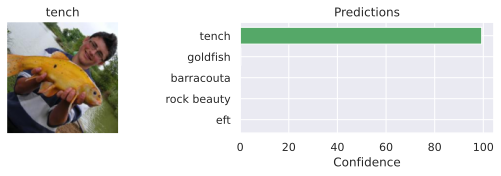

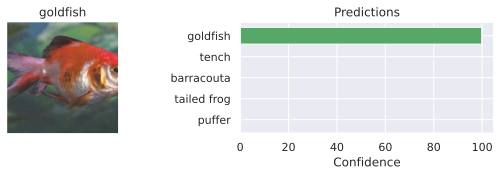

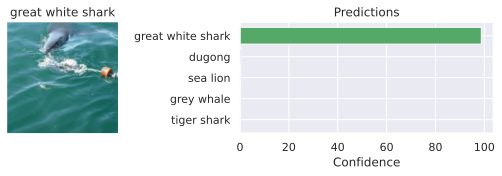

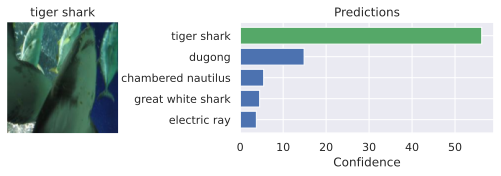

In [ ]:
exmp_batch, label_batch = next(iter(data_loader))
with torch.no_grad():
    preds = pretrained_model(exmp_batch.to(device))
for i in range(1,17,5):
    show_prediction(exmp_batch[i], label_batch[i], preds[i])

#### Training

In [ ]:
import torch
import torch.nn as nn # Import nn
import torch.optim as optim # Import optim
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import torchvision.transforms.functional as TF # Import TF for transformations
import random # Import random
import os # Import os
from tqdm import tqdm # Import tqdm


# Import exposure from skimage for better visualization contrast if available
try:
    from skimage import exposure
except ImportError:
    print("scikit-image not found, visualization might have lower contrast.")
    exposure = None


def create_simple_puzzle_init(patch_size=64, num_colors=3, line_thickness=3):
    """
    Overly simple jigsaw puzzle piece initialization for adversarial patch.

    Creates basic geometric puzzle pieces that just fit together without complex tabs/blanks.
    The pieces are simple shapes that interlock geometrically, letting training do the work.

    Args:
        patch_size: int - patch dimensions (64x64 recommended)
        num_colors: int - number of colors to use (cycles through palette; 2-4 for pieces)
        line_thickness: int - thickness of piece boundaries

    Returns:
        torch.FloatTensor (3, H, W) - initialization in [-3, 3] range
    """
    h, w = patch_size, patch_size
    init_patch = np.zeros((3, h, w))

    # Simple color palette - neutral colors for basic pieces
    colors = [
        [0.8, 0.8, 0.8],  # Light gray
        [0.6, 0.6, 0.6],  # Medium gray
        [0.4, 0.4, 0.4],  # Dark gray
        [0.7, 0.7, 0.5],  # Light beige
        [0.5, 0.5, 0.7]   # Light blue-gray
    ]

    # Create simple interlocking puzzle geometry
    boundaries = np.zeros((h, w))

    # Outer boundary - simple square frame
    border = line_thickness
    boundaries[:border, :] = 1.0  # Top
    boundaries[-border:, :] = 1.0  # Bottom
    boundaries[:, :border] = 1.0  # Left
    boundaries[:, -border:] = 1.0  # Right

    # Simple horizontal division at middle
    mid_y = h // 2
    boundaries[mid_y - border//2 : mid_y + border//2 + 1, :] = 1.0

    # Simple vertical division at middle (creates 4 quadrants)
    mid_x = w // 2
    boundaries[:, mid_x - border//2 : mid_x + border//2 + 1] = 1.0

    # Create basic interlocking shapes - simple geometric pieces
    # Piece 1: Top-left corner piece (L-shape)
    piece1_mask = np.zeros((h, w))
    piece1_mask[:mid_y, :mid_x] = 1.0  # Top-left quadrant
    # Extend bottom part to create L-shape interlocking
    piece1_mask[mid_y:mid_y+border*2, :mid_x] = 0.8

    # Piece 2: Top-right piece (extends down on right)
    piece2_mask = np.zeros((h, w))
    piece2_mask[:mid_y, mid_x:] = 1.0  # Top-right quadrant
    # Extend left part to interlock with piece 1
    piece2_mask[mid_y-border:mid_y, mid_x-border*2:mid_x] = 0.7

    # Piece 3: Bottom-left piece (extends right on bottom)
    piece3_mask = np.zeros((h, w))
    piece3_mask[mid_y:, :mid_x] = 1.0  # Bottom-left quadrant
    # Extend right part to interlock
    piece3_mask[mid_y-border:mid_y, mid_x:mid_x+border*2] = 0.6

    # Piece 4: Bottom-right corner piece
    piece4_mask = np.zeros((h, w))
    piece4_mask[mid_y:, mid_x:] = 1.0  # Bottom-right quadrant
    # Simple interlocking extension up
    piece4_mask[mid_y-border*2:mid_y, mid_x:] = 0.5

    # Color the pieces with simple, distinct colors
    pieces = [piece1_mask, piece2_mask, piece3_mask, piece4_mask]
    for i, mask in enumerate(pieces):
        if np.sum(mask) > 0:
            # Use different colors for each piece, cycling through palette
            color_idx = i % len(colors)
            color = np.array(colors[color_idx])
            # Create colored region
            colored_region = color[:, np.newaxis, np.newaxis] * mask[np.newaxis, :, :]
            init_patch += colored_region

    # Add simple boundaries between pieces (dark lines)
    boundary_color = np.array([0.2, 0.2, 0.2])  # Dark gray boundaries
    boundary_mask = boundaries > 0.5
    boundary_mask_3d = boundary_mask[np.newaxis, :, :]  # Add channel dimension
    colored_boundaries = boundary_color[:, np.newaxis, np.newaxis] * boundary_mask_3d
    init_patch += colored_boundaries

    # Ensure pieces don't overlap too much by normalizing
    init_patch = np.clip(init_patch, 0, 1)

    # Add subtle texture/noise to make it look more like puzzle pieces
    noise = np.random.normal(0, 0.05, init_patch.shape)
    init_patch += noise
    init_patch = np.clip(init_patch, 0, 1)

    # Scale to [-3, 3] range for adversarial training
    init_patch = 6 * (init_patch - 0.5)
    init_patch = np.clip(init_patch, -3, 3)

    return torch.FloatTensor(init_patch)


def visualize_simple_patch(patch, title="Simple Puzzle Patch", save_path=None):
    """Simple visualization with improved contrast handling."""
    # Detach gradients before visualization
    patch_detached = patch.detach()

    # Normalize for display (handle the [-3,3] range)
    viz = torch.clamp(patch_detached, -3, 3)
    viz = (viz + 3) / 6  # Map to [0,1]
    viz = viz.permute(1, 2, 0).numpy()  # Now safe to convert to numpy

    # Enhance contrast for better visibility if skimage is available
    if exposure is not None:
        try:
            # Apply adaptive histogram equalization to each channel
            viz_enhanced = np.zeros_like(viz)
            for c in range(3):
                viz_enhanced[:, :, c] = exposure.equalize_adapthist(
                    viz[:, :, c], clip_limit=0.03
                )
        except Exception as e:
            print(f"Error during contrast enhancement: {e}")
            viz_enhanced = viz
    else:
        viz_enhanced = viz

    plt.figure(figsize=(8, 8))
    plt.imshow(viz_enhanced)
    plt.title(title, fontsize=12, pad=20)
    plt.axis('off')

    # Add subtle border for scale reference
    plt.gca().add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                                    edgecolor='black', linewidth=2,
                                    transform=plt.gca().transAxes))

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=200, facecolor='white')
        plt.close()
        print(f"Visualization saved to {save_path}")
    else:
        plt.tight_layout()
        plt.show()


def place_patch_with_gradients(img, patch, h_offset, w_offset):
    """
    Place patch while preserving gradients using indexing.
    Assumes img and patch are on the same device.
    img shape: [B, C, H_img, W_img]
    patch shape: [B, C, H_patch, W_patch]
    """
    patched_img = img.clone()
    # Correct slicing to match patch dimensions
    patched_img[:, :, h_offset:h_offset+patch.shape[2], w_offset:w_offset+patch.shape[3]] = patch
    return patched_img


def puzzle_attack(model, target_class, patch_size=64, num_epochs=18,
                         lr=0.01, save_viz_dir=None, batch_size=16,
                         patch_size_range=(0.8, 1.2), rotation_range=(-15, 15)):
    """
    Improved targeted patch attack with simple puzzle initialization.
    """
    global device, dataset  # Assuming these are defined globally

    # Create data loaders with smaller batch size for better gradient signals
    train_size = min(2000, len(dataset))  # Use smaller dataset for faster training
    train_set, _ = torch.utils.data.random_split(dataset, [train_size, len(dataset) - train_size])
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                             shuffle=True, drop_last=True, num_workers=4)

    print(f"Using {len(train_set)} training samples with batch size {batch_size}")

    # Initialize simple puzzle patch
    if isinstance(patch_size, int):
        original_patch_size = (patch_size, patch_size)
    else:
        original_patch_size = patch_size

    print(f"Initializing simple geometric puzzle patch for target class {target_class}")
    raw_init = create_simple_puzzle_init(
        original_patch_size[0], num_colors=4, line_thickness=2
    ).to(device)

    # Make it a parameter with gradients
    patch = nn.Parameter(raw_init.clone().detach(), requires_grad=True)

    # Stronger optimizer settings
    optimizer = optim.Adam([patch], lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=3)

    # Use targeted cross-entropy loss
    criterion = nn.CrossEntropyLoss()

    # Setup visualization
    if save_viz_dir:
        os.makedirs(save_viz_dir, exist_ok=True)

    # Track attack success
    best_success_rate = 0.0
    best_patch = None
    num_batches = len(train_loader)

    print("Starting training...")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_success = 0
        total_samples = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        # Visualize patch at the beginning of the epoch
        viz_path = None
        if save_viz_dir and epoch % 5 == 0:  # Save every 5 epochs to reduce clutter
            viz_path = os.path.join(save_viz_dir, f'patch_epoch_{epoch+1:02d}.png')
        if viz_path or epoch == 0 or epoch == num_epochs-1:
            current_title = f"Epoch {epoch+1} - Best Success: {best_success_rate:.1%}"
            visualize_simple_patch(patch.cpu(), current_title, viz_path)

        for batch_idx, (images, _) in enumerate(pbar):
            images = images.to(device)
            batch_size_actual = images.shape[0]

            optimizer.zero_grad()

            # Apply random resizing and rotation to the patch
            scale_factor = random.uniform(patch_size_range[0], patch_size_range[1])
            new_patch_h = int(original_patch_size[0] * scale_factor)
            new_patch_w = int(original_patch_size[1] * scale_factor)
            new_patch_h = max(1, new_patch_h) # Ensure patch size is at least 1x1
            new_patch_w = max(1, new_patch_w) # Ensure patch size is at least 1x1

            # Ensure patch size is even for better processing
            new_patch_h = new_patch_h if new_patch_h % 2 == 0 else new_patch_h + 1
            new_patch_w = new_patch_w if new_patch_w % 2 == 0 else new_patch_w + 1

            if new_patch_h <= 0 or new_patch_w <= 0:
                continue # Skip this batch if patch becomes invalid size

            # Resize preserves gradients
            resized_patch = TF.resize(patch, [new_patch_h, new_patch_w], antialias=True)

            # Limited rotation
            angle = random.uniform(rotation_range[0], rotation_range[1])
            transformed_patch = TF.rotate(resized_patch, angle,
                                        interpolation=TF.InterpolationMode.BILINEAR)

            # Place transformed patch on images at random locations
            patched_img_batch = []
            valid_count = 0
            for single_img in images:
                # Random position for each image
                h_max = images.shape[2] - transformed_patch.shape[2]
                w_max = images.shape[3] - transformed_patch.shape[3]

                if h_max < 0 or w_max < 0: # Patch too large for this image
                    patched_img_batch.append(single_img.unsqueeze(0))
                    continue

                h_offset = random.randint(0, max(0, h_max))
                w_offset = random.randint(0, max(0, w_max))

                # Place patch
                single_img_unsqueeze = single_img.unsqueeze(0)
                single_patched = place_patch_with_gradients(
                    single_img_unsqueeze, transformed_patch.unsqueeze(0),
                    h_offset, w_offset
                )
                patched_img_batch.append(single_patched)
                valid_count += 1

            # Stack the patched images (only if we have valid ones)
            if valid_count > 0 and patched_img_batch:
                img = torch.cat(patched_img_batch, dim=0)

                # Forward pass
                outputs = model(img)
                targets = torch.full((img.shape[0],), target_class,
                                   dtype=torch.long, device=device)

                # Use sum instead of mean for stronger gradients
                loss = criterion(outputs, targets) * img.shape[0]

                # Backward pass
                loss.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_([patch], max_norm=1.0)

                optimizer.step()

                # Clamp patch to reasonable bounds
                with torch.no_grad():
                    patch.clamp_(-3.0, 3.0)

                epoch_loss += loss.item()
                epoch_success += (outputs.argmax(dim=1) == targets).sum().item()
                total_samples += img.shape[0]

                # Update progress bar
                success_rate = (outputs.argmax(dim=1) == targets).sum().item() / img.shape[0]
                pbar.set_postfix({
                    'Loss': f'{loss.item()/img.shape[0]:.3f}',
                    'Success': f'{success_rate:.1%}',
                    'Valid': f'{valid_count}/{batch_size_actual}'
                })
            else:
                pbar.set_postfix({'Warning': 'All patches skipped'})

        # Epoch statistics
        avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
        epoch_success_rate = epoch_success / total_samples if total_samples > 0 else 0

        scheduler.step(avg_loss)

        print(f"\nEpoch {epoch+1} - Avg Loss: {avg_loss:.4f}, "
              f"Success Rate: {epoch_success_rate:.2%}, LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best patch
        if epoch_success_rate > best_success_rate:
            best_success_rate = epoch_success_rate
            best_patch = patch.detach().clone()
            print(f"  New best success rate: {best_success_rate:.2%}")

    # Final evaluation on validation set
    print("\nFinal evaluation...")
    val_success_rate = evaluate_patch_effectiveness(model, best_patch if best_patch is not None else patch,
                                                  target_class, num_samples=200)

    print(f"\n=== FINAL RESULTS ===")
    print(f"Training Success Rate: {best_success_rate:.2%}")
    print(f"Validation Success Rate: {val_success_rate:.2%}")
    print(f"Target Class: {target_class}")

    # Final visualization
    final_title = f"Final Simple Puzzle Patch - Val Success: {val_success_rate:.1%}"
    if save_viz_dir:
        final_path = os.path.join(save_viz_dir, 'final_simple_puzzle_patch.png')
        visualize_simple_patch(best_patch.cpu() if best_patch is not None else patch.cpu(),
                             final_title, final_path)
    else:
        visualize_simple_patch(best_patch.cpu() if best_patch is not None else patch.cpu(), final_title)

    # Return the final patch and results
    final_patch = best_patch if best_patch is not None else patch
    results = {
        'train_success': best_success_rate,
        'val_success': val_success_rate,
        'target_class': target_class
    }

    return final_patch, results


def evaluate_patch_effectiveness(model, patch, target_class, num_samples=200):
    """
    Evaluate patch effectiveness on random samples with fixed placement.
    """
    model.eval()
    success_count = 0
    total_evaluated = 0

    # Get random samples
    indices = torch.randperm(len(dataset))[:num_samples]
    test_set = torch.utils.data.Subset(dataset, indices)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)

    # Use eval_device for evaluation (CPU for consistency)
    eval_device = torch.device("cpu")
    model.to(eval_device)
    patch = patch.to(eval_device)

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(eval_device)
            batch_size = images.shape[0]

            # Apply patch to batch with fixed size and position for consistent evaluation
            transformed_patch = TF.resize(patch, [64, 64], antialias=True)

            # Place patch at a fixed location (top-left corner) for evaluation
            h_offset = 0
            w_offset = 0

            # Ensure patch fits on image
            if (transformed_patch.shape[2] <= images.shape[2] and
                transformed_patch.shape[3] <= images.shape[3]):

                patched_images = images.clone()
                patched_images[:, :, h_offset:h_offset+transformed_patch.shape[2],
                              w_offset:w_offset+transformed_patch.shape[3]] = transformed_patch

                # Evaluate
                outputs = model(patched_images)
                predictions = outputs.argmax(dim=1)
                batch_success = (predictions == target_class).sum().item()
                success_count += batch_success
                total_evaluated += batch_size
            else:
                # If patch doesn't fit, evaluate original images (should all fail)
                outputs = model(images)
                predictions = outputs.argmax(dim=1)
                batch_success = (predictions == target_class).sum().item()
                success_count += batch_success
                total_evaluated += batch_size

    # Move model and patch back to original device
    model.to(device)
    patch = patch.to(device)

    return success_count / total_evaluated if total_evaluated > 0 else 0.0

In [ ]:
import torchvision.models as models

# 1. Load the ResNet34 weights object
weights = models.ResNet34_Weights.IMAGENET1K_V1

# 2. Access the class categories or labels from the metadata
categories = weights.meta["categories"]

# 3. Find the index for the specific class "jigsaw puzzle"
target_class_name = "jigsaw puzzle"
try:
    class_index = categories.index(target_class_name)

    print(f"Class Name: '{target_class_name}'")
    print(f"Target Class Index: {class_index}")

    # You can also verify the label at that index
    print(f"Label at index {class_index}: '{categories[class_index]}'")

except ValueError:
    print(f"The class '{target_class_name}' was not found in the ImageNet categories.")

Class Name: 'jigsaw puzzle'
Target Class Index: 611
Label at index 611: 'jigsaw puzzle'


In [ ]:
target_class_name = "jigsaw puzzle"
class_index = categories.index(target_class_name)

print(f"Class Name: '{target_class_name}'")
print(f"Target Class Index: {class_index}")

The goal is to make a target class look like a jigsaw puzzle. I think to feel evil and make this maximally damaging to the public, I should go with the traffic light!

In [ ]:
TARGET_CLASS = 920
SAVE_DIR = '/content/puzzle_attack'

print("\n" + "—"*50)
print("        Adversarial Patch Training.       ")
print("—"*50 + "\n")

# Run the attack
final_patch, results = puzzle_attack(
    model=pretrained_model,
    target_class=TARGET_CLASS,
    patch_size=86,
    num_epochs=18,
    save_viz_dir=SAVE_DIR,
    num_pieces=4,
    line_thickness=5,
    lr=0.01,
    dataset=dataset
)

print("\n" + "—"*50)
print("              Attack Finished")
print("—"*50)


——————————————————————————————————————————————————
        Adversarial Patch Training.       
——————————————————————————————————————————————————

Visualization saved to /content/puzzle_attack/puzzle_patch_epoch_0.png


Epoch 1/18: 100%|██████████| 125/125 [00:07<00:00, 17.26it/s, Loss=5.837, Success=12.5%]


Epoch 1/18 - Loss: 9.2757, Success: 3.90%


Epoch 2/18: 100%|██████████| 125/125 [00:07<00:00, 16.98it/s, Loss=1.030, Success=75.0%]


Epoch 2/18 - Loss: 2.2365, Success: 56.20%


...

Epoch 16/18 - Loss: 0.0704, Success: 98.20%


Epoch 17/18: 100%|██████████| 125/125 [00:07<00:00, 17.39it/s, Loss=0.015, Success=100.0%]


Epoch 17/18 - Loss: 0.0787, Success: 98.10%


Epoch 18/18: 100%|██████████| 125/125 [00:07<00:00, 17.37it/s, Loss=0.061, Success=100.0%]


Epoch 18/18 - Loss: 0.0748, Success: 98.10%
Visualization saved to /content/puzzle_attack/final_puzzle_patch.png

Final Results:
Training Success: 98.10%
Validation Success: 99.00%
Target Class: 611

——————————————————————————————————————————————————
              Attack Finished
——————————————————————————————————————————————————


In [ ]:
from IPython.display import Image, display
import os

In [ ]:
viz_dir = '/content/puzzle_attack'

One nice thing about the initialization is how it does look like a jigsaw puzzle

The initialized image (before 1st epoch):

Displaying first image: /content/puzzle_attack/puzzle_patch_epoch_0.png


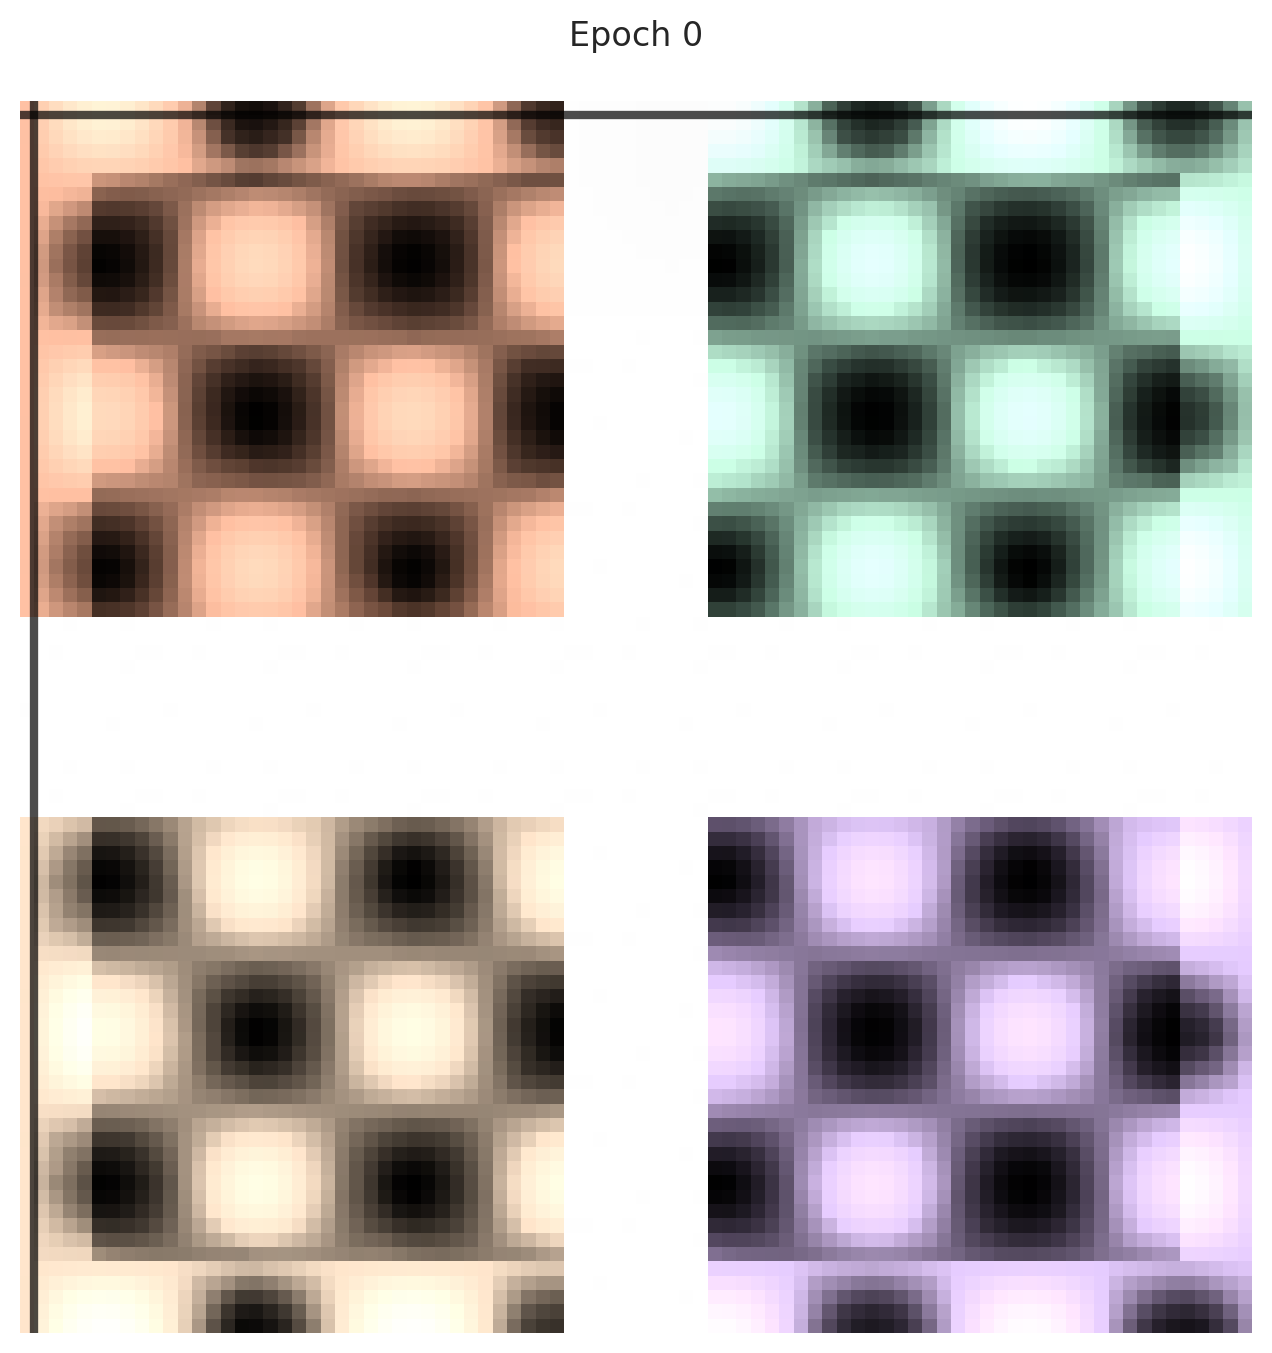

In [ ]:
first_image_path = os.path.join(viz_dir, 'puzzle_patch_epoch_0.png')

print(f"Displaying first image: {first_image_path}")
display(Image(first_image_path))

But after these epoches, the final image resembles a much more complex pattern.

The final image post-training looks like:

Displaying image: /content/puzzle_attack/final_puzzle_patch.png


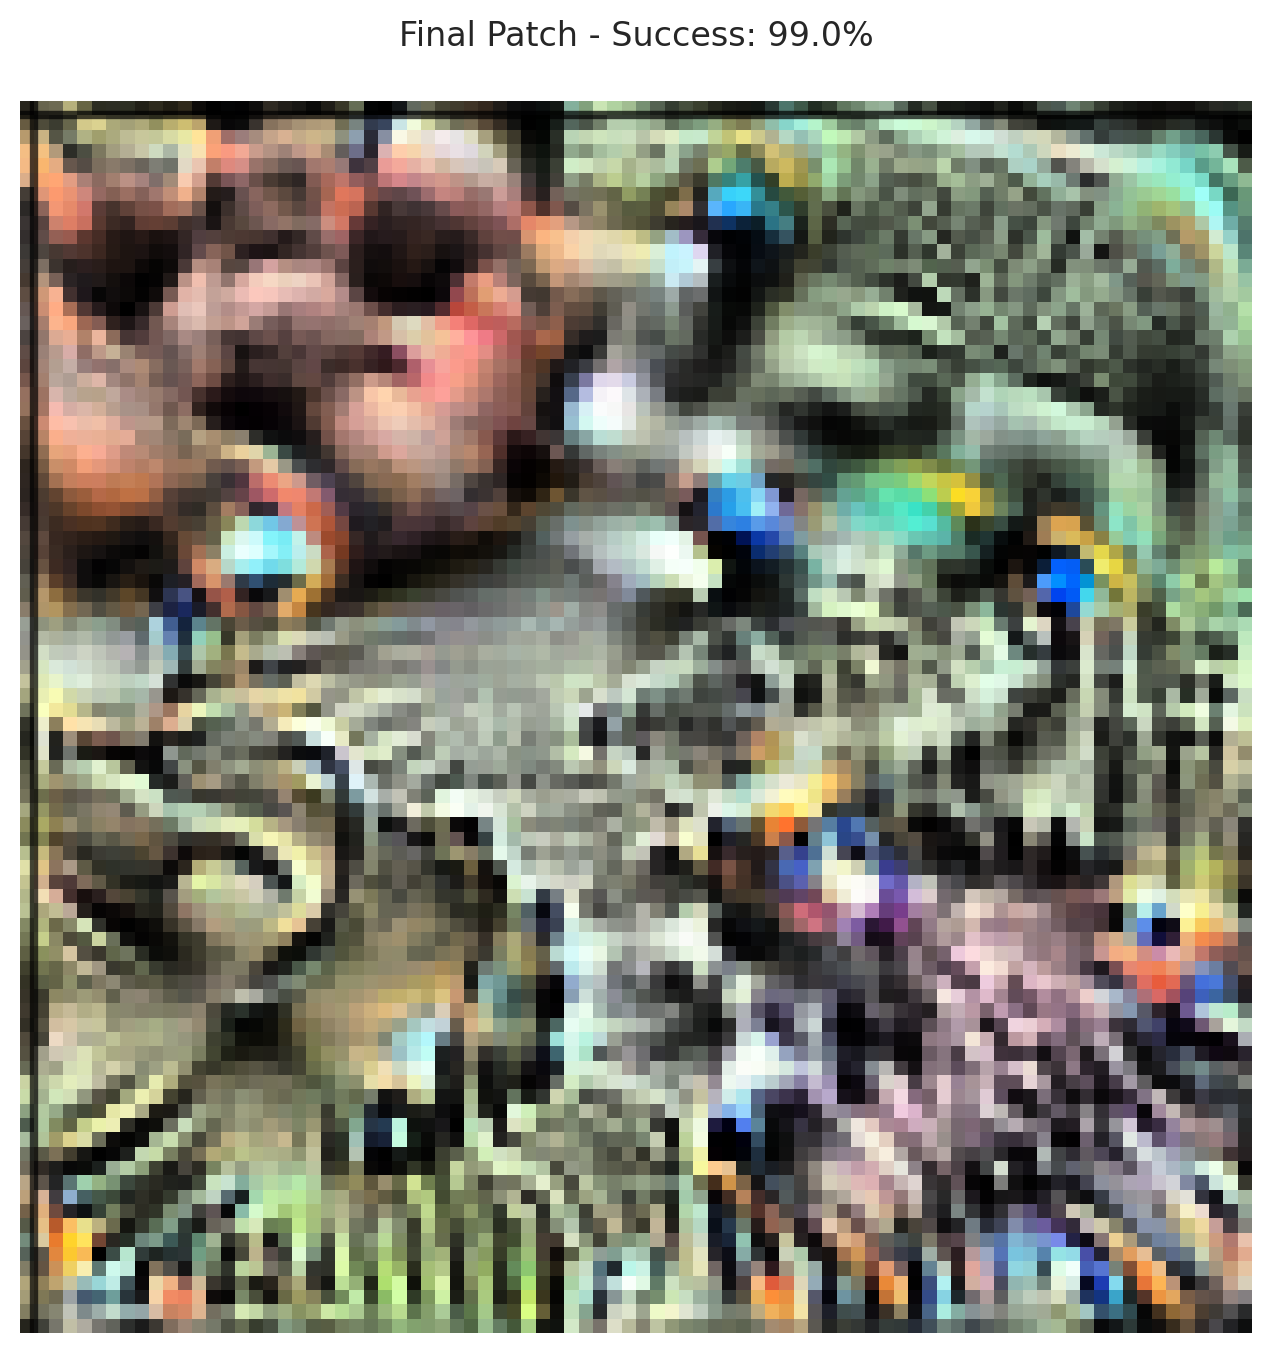

In [ ]:
final_image_path = os.path.join(viz_dir, 'final_puzzle_patch.png')

print(f"Displaying image: {final_image_path}")
display(Image(final_image_path))


Using final_patch with shape: torch.Size([3, 86, 86])
Displaying final patch image: /content/puzzle_attack/final_puzzle_patch.png


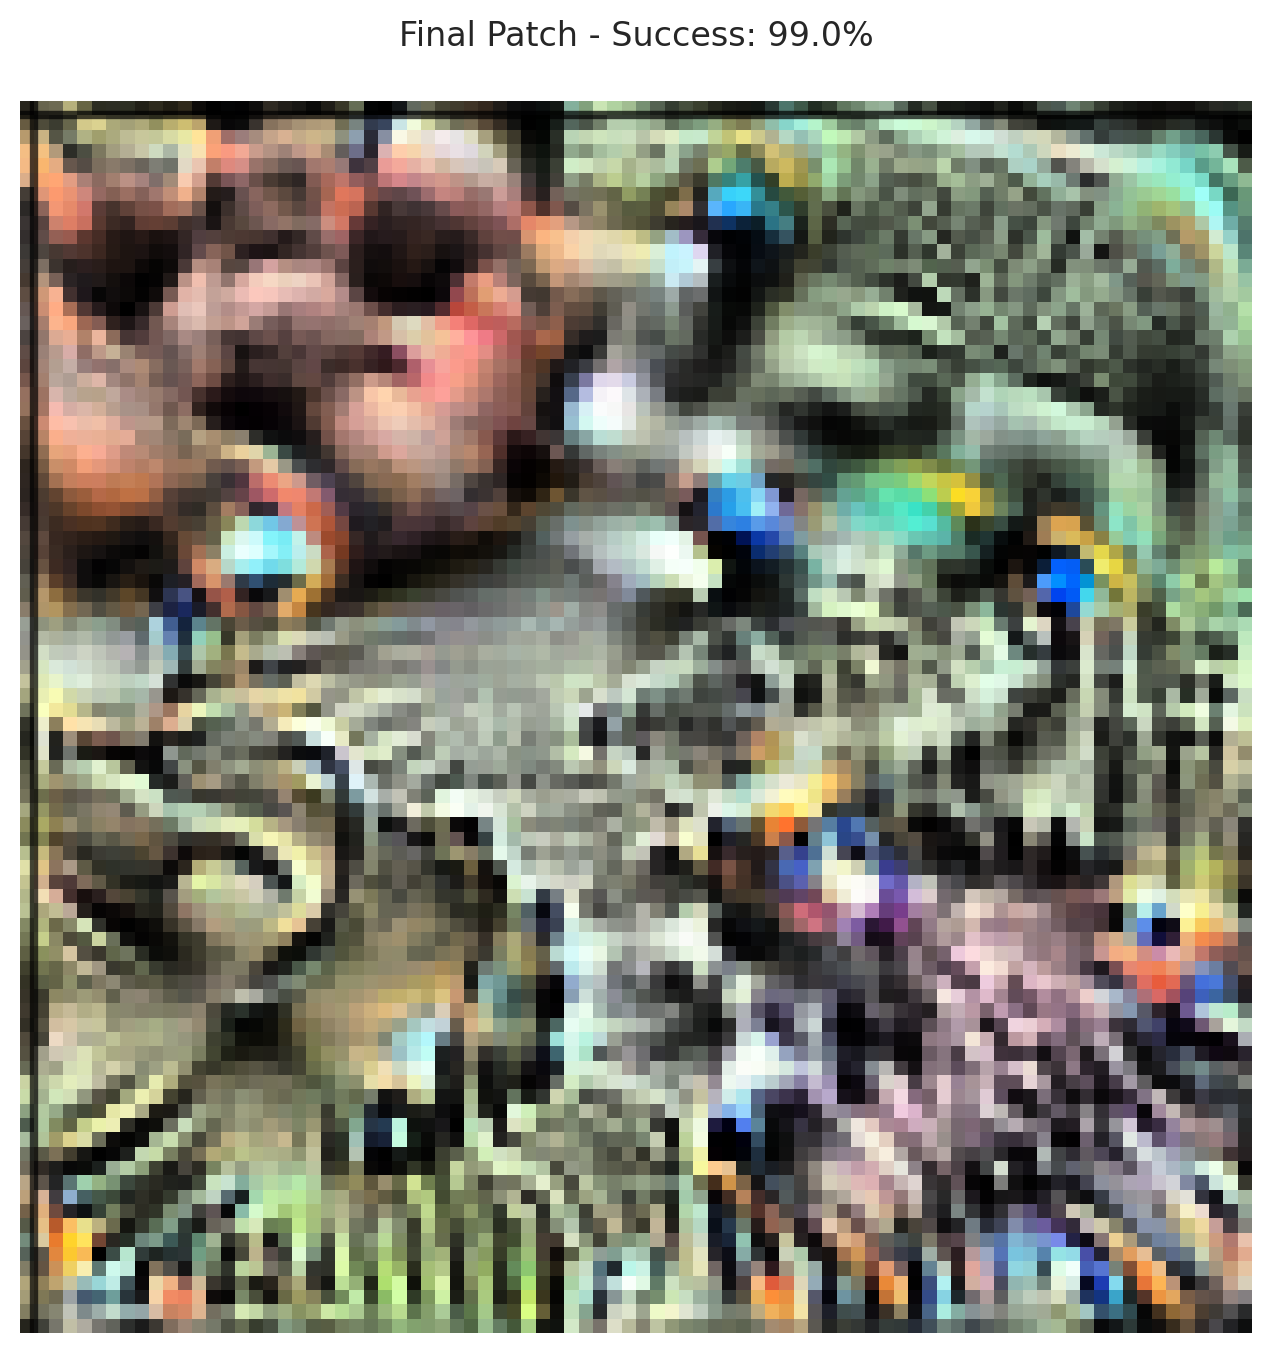


TESTING ADVERSARIAL PATCH ON ORIGINAL IMAGES

--- Image 30/10 ---
Original Label: electric ray
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: spatula
Attack ✗ - Target: jigsaw puzzle


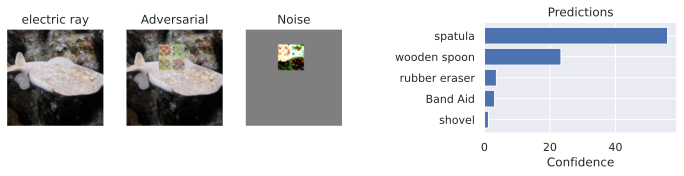


--- Image 6/10 ---
Original Label: goldfish
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: Band Aid
Attack ✗ - Target: jigsaw puzzle


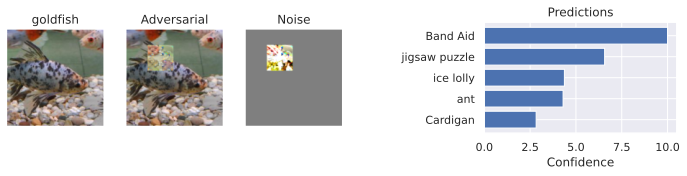


--- Image 9/10 ---
Original Label: goldfish
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: eft
Attack ✗ - Target: jigsaw puzzle


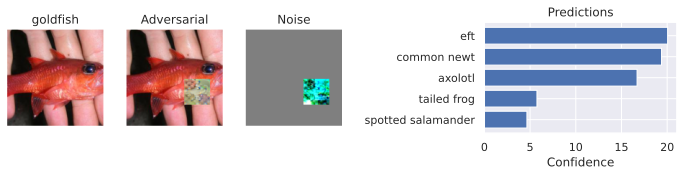


--- Image 12/10 ---
Original Label: great white shark
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: screw
Attack ✗ - Target: jigsaw puzzle


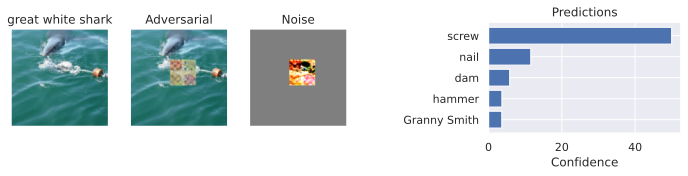


--- Image 4/10 ---
Original Label: tench
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: tusker
Attack ✗ - Target: jigsaw puzzle


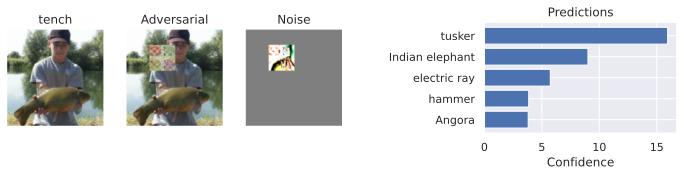


--- Image 5/10 ---
Original Label: tench
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: tench
Attack ✗ - Target: jigsaw puzzle


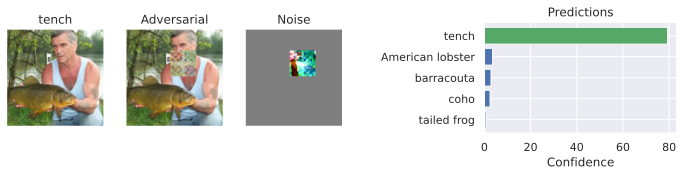


--- Image 2/10 ---
Original Label: tench
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: zucchini
Attack ✗ - Target: jigsaw puzzle


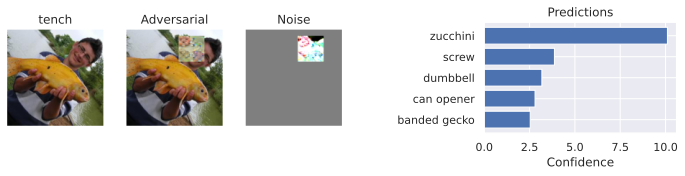


--- Image 10/10 ---
Original Label: goldfish
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: tick
Attack ✗ - Target: jigsaw puzzle


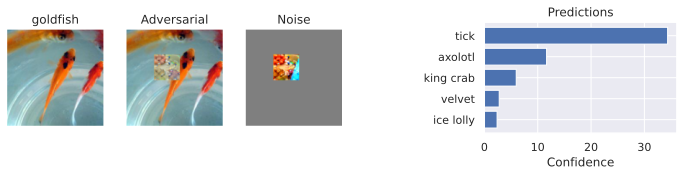


--- Image 15/10 ---
Original Label: great white shark
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: promontory
Attack ✗ - Target: jigsaw puzzle


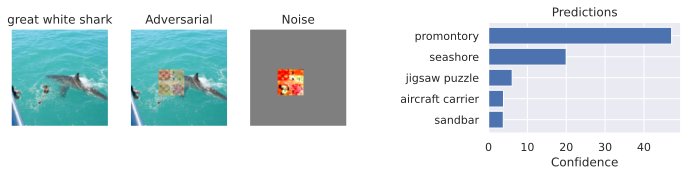


--- Image 28/10 ---
Original Label: electric ray
Placing patch of size: torch.Size([3, 60, 60])
With Patch - Predicted: velvet
Attack ✗ - Target: jigsaw puzzle


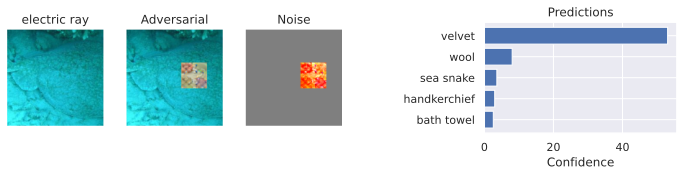


PATCH PLACEMENT TEST COMPLETE


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import random
import torchvision.transforms.functional as TF
from IPython.display import Image, display
import os
import torch

num_images_to_show = 10
patch_size_ratio = 0.7

# Get a batch of images
exmp_batch, label_batch = next(iter(data_loader))

# Select random indices from the batch
random_indices = random.sample(range(exmp_batch.shape[0]), min(num_images_to_show, exmp_batch.shape[0]))

# Move everything to CPU for evaluation and display
eval_device = torch.device("cpu")
exmp_batch_eval = exmp_batch.to(eval_device)
label_batch_eval = label_batch.to(eval_device)
pretrained_model.to(eval_device)

# Use the final patch (move to CPU if needed)
if 'final_patch' not in locals():
    print("Error: 'final_patch' variable not found. Please run the training cell first.")
else:
    final_patch_eval = final_patch.to(eval_device)
    print(f"Using final_patch with shape: {final_patch_eval.shape}")

    # Display the final patch visualization if available
    viz_dir = '/content/puzzle_attack'
    final_image_path_png = os.path.join(viz_dir, 'final_puzzle_patch.png')
    if os.path.exists(final_image_path_png):
        print(f"Displaying final patch image: {final_image_path_png}")
        display(Image(final_image_path_png))
    else:
        print(f"Final patch visualization not found: {final_image_path_png}")

    # Simple patch placement function - just random position, no transformations
    def place_patch_simple(img, patch):
        """Place patch at random position on image - no transformations."""
        # Ensure same device
        img = img.to(patch.device)
        patch = patch.to(img.device)

        # Get dimensions (assuming CHW format)
        if len(img.shape) == 4:  # Batch format (B, C, H, W)
            c, h_img, w_img = img.shape[1], img.shape[2], img.shape[3]
            c_patch, h_patch, w_patch = patch.shape[0], patch.shape[1], patch.shape[2]
        else:  # Single image (C, H, W)
            c, h_img, w_img = img.shape[0], img.shape[1], img.shape[2]
            c_patch, h_patch, w_patch = patch.shape[0], patch.shape[1], patch.shape[2]

        # Check if patch fits
        if h_patch > h_img or w_patch > w_img:
            print(f"Warning: Patch {h_patch}x{w_patch} too large for image {h_img}x{w_img}")
            return img

        # Random position
        h_offset = random.randint(0, h_img - h_patch)
        w_offset = random.randint(0, w_img - w_patch)

        # Clone image
        patched_img = img.clone()

        # Place patch - simple direct assignment
        if len(img.shape) == 4:
            # Batch format
            patched_img[:, :, h_offset:h_offset+h_patch, w_offset:w_offset+w_patch] = patch.unsqueeze(0)
        else:
            # Single image format
            patched_img[:, h_offset:h_offset+h_patch, w_offset:w_offset+w_patch] = patch

        return patched_img

    # Process and display images
    print("\n" + "="*80)
    print("TESTING ADVERSARIAL PATCH ON ORIGINAL IMAGES")
    print("="*80)

    for idx in random_indices:
        # Get original image and label
        original_image = exmp_batch_eval[idx]  # Already on CPU
        original_label = label_batch_eval[idx]

        print(f"\n--- Image {idx+1}/{len(random_indices)} ---")
        print(f"Original Label: {label_names[original_label.item()]}")

        # Resize patch to desired size
        original_patch_size = final_patch_eval.shape[1]
        new_patch_size = int(original_patch_size * patch_size_ratio)
        new_patch_size = max(1, new_patch_size)
        new_patch_size = new_patch_size if new_patch_size % 2 == 0 else new_patch_size + 1

        # Simple resize (no other transformations)
        resized_patch = TF.resize(final_patch_eval, [new_patch_size, new_patch_size])
        print(f"Placing patch of size: {resized_patch.shape}")

        # Place patch at random position
        patched_image = place_patch_simple(original_image.unsqueeze(0), resized_patch)
        patched_image = patched_image.squeeze(0)  # Remove batch dimension

        # Get prediction
        with torch.no_grad():
            preds = pretrained_model(patched_image.unsqueeze(0))
            predicted_class = preds.argmax(dim=-1).item()
            target_class_name = label_names[predicted_class]

        print(f"With Patch - Predicted: {target_class_name}")
        success = "✓ SUCCESS!" if predicted_class == TARGET_CLASS else "✗ Failed"
        print(f"Attack {'✓' if predicted_class == TARGET_CLASS else '✗'} - Target: {label_names[TARGET_CLASS]}")

        # Calculate noise (difference between patched and original)
        noise = patched_image - original_image

        # Display results
        show_prediction(
            original_image,
            original_label,
            preds.squeeze(0),
            adv_img=patched_image,
            noise=noise
        )

    print("\n" + "="*80)
    print("PATCH PLACEMENT TEST COMPLETE")
    print("="*80)

# Move model back to original device
pretrained_model.to(device)

The results, however, for applying the patch to the original images, were not great. The "jigsaw" did show up in some of the top 5 for some images, but not all. Perhaps retraining and another type of initialization is needed.

Also, the jigsaw class itself is tricky, as it contains interlocking patterns that are hard to find in other classes